### Discovery

Welcome new data analyst contractor, to Fictional Care Co. Whilst on your generous and extremely interesting 30 second induction, your IT systems have been fully set up, tested and everything is working perfectly. <br><br>
As your first task, you will be trying to determine if there is a linear relationship between patient characteristics and their cholesterol levels for patients living with diabetes. You will use a linear regression model to establish if any relationship exists and if so, how cholesterol levels vary by patient. Data has already been sourced by the ever efficient and humble management team. You can find a full breakdown of the fields contained within the dataset below:

--- 
### Data preparation


First we will import the required modules. They are:
- Pandas
- Seaborn
- Statsmodels.api
- Sklearn.model_selection - train_test_split

In [2]:
# Import required modules
import pandas as pd # Used for manipulating data
import seaborn as sns # Visualisations
import statsmodels.api as sm # One of the ML libraries
from sklearn.model_selection import train_test_split # Another ML library
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt # Another viz library

Import the diabetes dataset and validate the results. 

In [3]:
# Import the first dataset and set the date as the index
diabetes_df = pd.read_csv("diabetes.csv")
diabetes_df

,Age,Gender,BMI,SBP,DBP,FPG,Chol,Tri,HDL,LDL,ALT,BUN,CCR,FFPG,smoking,drinking,family_histroy,Diabetes
0,26,1,20.1,119,81,5.80,4.36,0.86,0.90,2.43,12.0,5.40,63.8,5.40,3.000000,3.000000,0,0
1,40,1,17.7,97,54,4.60,3.70,1.02,1.50,2.04,9.2,3.70,70.3,4.10,1.000000,1.000000,0,0
2,40,2,19.7,85,53,5.30,5.87,1.29,1.75,3.37,10.1,4.10,61.1,4.85,3.000000,3.000000,0,0
3,43,1,23.1,111,71,4.50,4.05,0.74,1.27,2.60,36.5,4.38,73.4,5.30,2.000000,3.000000,0,0
4,36,1,26.5,130,82,5.54,6.69,3.49,0.91,3.64,69.3,3.86,67.5,5.53,3.000000,3.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4298,54,1,23.4,126,75,6.82,5.00,1.50,1.24,2.98,8.0,3.50,77.0,6.70,1.000000,3.000000,0,1
4299,50,2,22.3,115,84,5.32,4.37,2.09,1.37,2.29,21.2,4.40,47.3,6.55,4.860753,4.860753,0,1
4300,67,1,24.6,138,81,4.85,3.89,1.38,1.14,2.17,18.1,4.73,70.6,6.80,3.000000,3.000000,0,1
4301,60,2,29.0,101,60,6.70,5.91,1.29,1.73,2.85,18.9,7.33,50.2,7.00,3.000000,3.000000,0,1


--- 
### Model planning
You will now need to understand which variables have a relationship from the prepared data. Identifying the strength and direction of the relationships will help you to build a useful model, within the remit of the task. <br><br>
Create a correlation matrix, to establish which variables you wish to use. We will only use 1 indepednent and 1 depedant variable for this model. 

In [4]:
# Use price as dependent and select another appropriate variable to predict the output. 
dia_corr = diabetes_df.corr()
dia_corr

,Age,Gender,BMI,SBP,DBP,FPG,Chol,Tri,HDL,LDL,ALT,BUN,CCR,FFPG,smoking,drinking,family_histroy,Diabetes
Age,1.000000,0.004783,0.232346,0.437992,0.230389,0.370798,0.242679,0.163353,0.213133,0.295938,-0.036210,0.276961,0.023667,0.359268,0.244430,0.370963,-0.037955,0.521380
Gender,0.004783,1.000000,-0.252456,-0.125792,-0.186603,-0.073297,0.055566,-0.155444,0.072716,0.001364,-0.235779,-0.147157,-0.602743,-0.049288,0.261566,0.158599,0.066452,0.007251
BMI,0.232346,-0.252456,1.000000,0.328772,0.318889,0.270508,0.173834,0.315455,0.047260,0.201447,0.343488,0.107482,0.155089,0.247893,0.036824,0.105632,0.013928,0.236583
SBP,0.437992,-0.125792,0.328772,1.000000,0.651806,0.263391,0.164950,0.196480,0.089887,0.167468,0.111913,0.143541,0.088885,0.221215,0.139364,0.180866,-0.052285,0.282476
DBP,0.230389,-0.186603,0.318889,0.651806,1.000000,0.178995,0.141619,0.194973,0.048761,0.146217,0.158603,0.087696,0.103241,0.167874,0.037215,0.084919,-0.012258,0.169963
FPG,0.370798,-0.073297,0.270508,0.263391,0.178995,1.000000,0.163499,0.212294,0.201780,0.239304,0.113730,0.169327,0.039803,0.473931,0.278685,0.348008,0.001427,0.515342
Chol,0.242679,0.055566,0.173834,0.164950,0.141619,0.163499,1.000000,0.335038,0.114105,0.651530,0.151360,0.129534,-0.004502,0.106131,0.038658,0.075083,-0.002684,0.124310
Tri,0.163353,-0.155444,0.315455,0.196480,0.194973,0.212294,0.335038,1.000000,0.048405,0.158445,0.245089,0.044594,0.090810,0.165935,-0.004733,0.055889,0.012511,0.169151
HDL,0.213133,0.072716,0.047260,0.089887,0.048761,0.201780,0.114105,0.048405,1.000000,0.655013,0.005198,0.056119,-0.147407,0.244480,0.262487,0.295627,0.039533,0.453618
LDL,0.295938,0.001364,0.201447,0.167468,0.146217,0.239304,0.651530,0.158445,0.655013,1.000000,0.120501,0.129122,-0.061717,0.242597,0.176180,0.254001,0.026949,0.386235


Strip out some of the values from the dataset, I want to include the following columns:
- Chol
- Age
- Tri
- LDL

In [5]:
diabetes_df = diabetes_df [["Chol","Age","Tri","LDL"]]
diabetes_df

,Chol,Age,Tri,LDL
0,4.36,26,0.86,2.43
1,3.70,40,1.02,2.04
2,5.87,40,1.29,3.37
3,4.05,43,0.74,2.60
4,6.69,36,3.49,3.64
...,...,...,...,...
4298,5.00,54,1.50,2.98
4299,4.37,50,2.09,2.29
4300,3.89,67,1.38,2.17
4301,5.91,60,1.29,2.85


<Axes: >

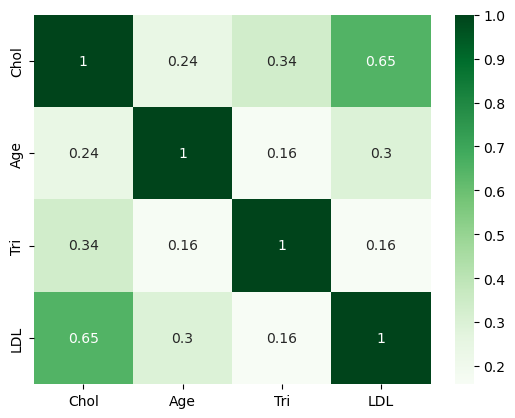

In [6]:
# (Optional) Generate the matrix as a heatmap visual
dia_corr = diabetes_df.corr()
sns.heatmap(dia_corr, annot=True, cmap="Greens")

Create a Regplot/Scatterplot to demonstrate the relationship between our dependent and independent variable. 

<Axes: xlabel='Tri', ylabel='Chol'>

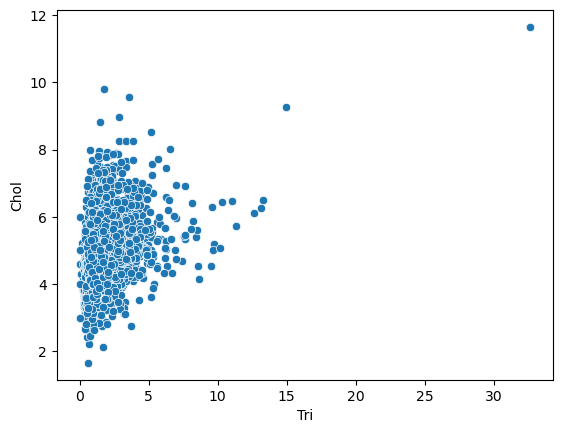

In [7]:
# Check the relationship between the selected variables
sns.scatterplot(x = "Tri",
            y = "Chol",
            data = diabetes_df)

---
### Building the model
Split the data into training and test datasets - include the random_state argument:<br>
random_state = 25

In [8]:
# Split the data into train and test samples
train, test = train_test_split(diabetes_df,random_state=10)
train.head()

,Chol,Age,Tri,LDL
1843,6.10,43,1.61,3.88
3138,4.53,66,3.53,2.80
1489,4.58,33,0.47,2.61
628,4.00,42,0.23,2.13
1133,3.61,37,0.39,1.80


Set both the independent variable and dependent variable - remember to check they are set correctly. Don't forget to add a constant to your independent variables. 

In [9]:
# Set the dependent variable and validate
dep = train["Chol"]
dep.head()

1843    6.10
3138    4.53
1489    4.58
628     4.00
1133    3.61
Name: Chol, dtype: float64

In [10]:
# Set the independent variable and validate
ind = train[["LDL","Tri","Age"]]
ind.head()

,LDL,Tri,Age
1843,3.88,1.61,43
3138,2.80,3.53,66
1489,2.61,0.47,33
628,2.13,0.23,42
1133,1.80,0.39,37


In [11]:
# Remember to add the constant and validate
ind = sm.add_constant(ind)
ind.head()

,const,LDL,Tri,Age
1843,1.0,3.88,1.61,43
3138,1.0,2.80,3.53,66
1489,1.0,2.61,0.47,33
628,1.0,2.13,0.23,42
1133,1.0,1.80,0.39,37


Now generate the model along with a summary output. 

In [12]:
# Fit the model and produce the summary
model = sm.OLS(dep,ind).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Chol   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     972.0
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        14:51:10   Log-Likelihood:                -3250.6
No. Observations:                3227   AIC:                             6509.
Df Residuals:                    3223   BIC:                             6533.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6734      0.050     53.663      0.000       2.576       2.771
LDL            0.6211      0.014     45.316      0.000       0.594       0.648
Tri            0.1638      0.009     17.855      0.000       0.146       0.182
Age            0.0014      0.001      1.694      0.090      -0.000       0.003
==============================================================================
Omnibus:                      325.239   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              752.768
Skew:                          -0.606   Prob(JB):                    3.46e-164
Kurtosis:                       5.033   Cond. No.                         218.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

--- 
### Communicating the results. 
You will now analyse the model and communicate the results. What do the following outputs tell you about the model

- R-Squared: 
- F-Statistic: 
- Prob (F-Statistic):
- P-Value:
- Coefficient:
- Constant:

Now lets test the model output - remember to add a constant to your test data. 

In [13]:
# Set the test sample independent variable and use the model to predict the variable, using the test dataset 
test_ind = test[["LDL"]]
test_dep = test[["Chol"]]
test_ind = sm.add_constant(test_ind)


print(test_dep.shape)
print(test_ind.shape)

(1076, 1)
(1076, 2)


In [14]:
# Add the predicted values to our test dataframe to compare actual with predicted. 
test["predicted"] = model.predict(test_ind)
test[["LDL","Chol","predicted"]]

ValueError: shapes (1076,2) and (4,) not aligned: 2 (dim 1) != 4 (dim 0)

In [ ]:
# Plot the actual, compared with predicted. 
# Should be on a 45° incline to show good predictions.
import matplotlib.pyplot as plt
sns.scatterplot(x="Chol", y="predicted", data = test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
# Plot redsiduals to understand dispersion of outliers.
# Should be centered around 0

residuals = test["Chol"] - test["predicted"]
sns.scatterplot(x=test["predicted"], y=residuals, data = test)

plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()



In [ ]:
# Plot the distribution of residuals 
# Should look like a bell-curve when correct
sns.histplot(residuals, kde=True)

plt.xlabel("Residuals")
plt.title("Residual Distribution")

plt.show()

Finally, add a predicted column to your test dataset, where you have your prediction shown, alongside your actual values for your dependent variable. 

In [ ]:
test.head()

Now you have genereated some predictions with the test data, explain the output by way of the formula Y = mX + C

---
### Stretch task
Create a new dataframe with some example data, and generate some predictions using your model.

--- 

In [ ]:
# Create a new dataframe

In [ ]:
# Generate predictions

In [ ]:
# Generate results in the dataframe based on new dataset

--- 
### Operationalise
In the real world, this is where you would draft a report, deliver briefings, implement with automation on production level servers, produce technical documentation and build this into your BAU process. This being a fictional company, the ever grateful management have granted you paid leave for all your hard work and have volunteered to take on this burden themselves. Congratulations and well done!